In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sentence_transformers import InputExample
from sentence_transformers.sentence_transformer import losses
from sentence_transformers.sentence_transformer.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers import losses
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import json, warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


/tmp/ipykernel_3377/1612975165.py:9: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import losses


In [ ]:
# Load the cleaned ATS pairs dataset
df = pd.read_csv('../Dataset/cleaned_dataset.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')
df.head(3)

dataset = df.copy()

Loaded: 500 pairs

Label distribution:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Score range: 0.05 – 0.98


In [4]:
dataset.head(10)

,resume_text,job_description,match_score,match_label
0,Name: Kritika Shah || Email: kritika.shah55@gm...,Job Title: FP&A Analyst || Company: Amazon | L...,0.55,partial match
1,Name: Arjun Verma || Email: arjun.verma70@gmai...,Job Title: Design Lead || Company: Paytm | Loc...,0.27,no match
2,Name: Manish Bhatt || Email: manish.bhatt89@gm...,Job Title: Security Analyst || Company: KPMG |...,0.46,partial match
3,Name: Natasha Sharma || Email: natasha.sharma7...,Job Title: Sales Director || Company: Ola | Lo...,0.09,no match
4,Name: Kavya Agarwal || Email: kavya.agarwal75@...,Job Title: Business Development Manager || Com...,0.66,partial match
5,Name: Divya Bhatt || Email: divya.bhatt72@gmai...,Job Title: Senior Data Scientist || Company: E...,0.11,no match
6,Name: Varun Naidu || Email: varun.naidu97@gmai...,Job Title: Investment Analyst || Company: upGr...,0.95,match
7,Name: Vikram Singh || Email: vikram.singh43@gm...,Job Title: Financial Analyst || Company: Zoho ...,0.17,no match
8,Name: Ananya Joshi || Email: ananya.joshi19@gm...,Job Title: Group Product Manager || Company: Z...,0.75,match
9,Name: Rishabh Banerjee || Email: rishabh.baner...,Job Title: Recruiter || Company: Flipkart | Lo...,0.94,match


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      500 non-null    object 
 1   job_description  500 non-null    object 
 2   match_score      500 non-null    float64
 3   match_label      500 non-null    object 
 4   resume_text_len  500 non-null    int64  
 5   jd_length        500 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 23.6+ KB


In [8]:
dataset.describe()

,match_score,resume_text_len,jd_length
count,500.000000,500.000000,500.000000
mean,0.529720,160.970000,157.088000
std,0.283882,7.079077,5.462227
min,0.050000,142.000000,144.000000
25%,0.280000,156.000000,153.000000
50%,0.540000,161.000000,157.000000
75%,0.790000,165.000000,161.000000
max,0.980000,184.000000,172.000000


In [9]:
train_df, temp_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=dataset['match_label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['match_label']   # ✅ use temp_df here
)

print(f'Train : {len(train_df)} pairs')
print(f'Validation : {len(val_df)} pairs')
print(f'Test : {len(test_df)} pairs')


Train : 400 pairs
Validation : 50 pairs
Test : 50 pairs


In [10]:
# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')



Train label dist: {'no match': 152, 'match': 126, 'partial match': 122}
Val label dist: {'no match': 19, 'match': 16, 'partial match': 15}
Test label dist: {'no match': 19, 'match': 16, 'partial match': 15}


In [11]:

# Training examples
train_examples = [
    InputExample(
        texts=[row['resume_text'], row['job_description']],
        label=float(row['match_score'])
    )
    for _, row in train_df.iterrows()
]

# Validation examples
val_examples = [
    InputExample(
        texts=[row['resume_text'], row['job_description']],
        label=float(row['match_score'])
    )
    for _, row in val_df.iterrows()
]

In [12]:
print(f"Train examples: {len(train_examples)}")
print(f"Val examples: {len(val_examples)}")

print("\nSample InputExample:")
print(f" text1 (resume): {train_examples[0].texts[0][:80]}...")
print(f" text2 (JD)    : {train_examples[0].texts[1][:80]}...")
print(f" label         : {train_examples[0].label}")


Train examples: 400
Val examples: 50

Sample InputExample:
 text1 (resume): Name Gaurav Malhotra  Email gaurav.malhotra26gmail.com  Phone +91-8148872110  Li...
 text2 (JD)    : Job Title Head of DevOps  Company Adobe  Location Chennai / Remote  Type Full-Ti...
 label         : 0.68


In [13]:
#Base Model Baseline
print('Loading base BERT model...')
base_model = SentenceTransformer('all-mpnet-base-v2')
print('Loaded.')


Loading base BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded.


In [14]:
base_preds = list()
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim  = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
    base_preds.append(float(sim))

base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))
base_spearman = spearmanr(test_df['match_score'], base_preds)

print(f'\nBase Model — Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print(f'  Spearman: {base_spearman[0]:.4f} (p={base_spearman[1]:.4g})')
print()
print('Goal: fine-tuning should reduce MAE below this number.')


Base Model — Test Set Performance
  MAE:  0.2222
  RMSE: 0.2761
  Spearman: 0.5618 (p=2.184e-05)

Goal: fine-tuning should reduce MAE below this number.


In [15]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [16]:
#Fine-Tune BERT

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer('all-mpnet-base-v2')

# DataLoader, shuffles training data each epoch
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# CosineSimilarityLoss: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score
train_loss = losses.CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size:   16')
print(f'  Train pairs:  {len(train_examples)}')
print(f'  Steps/epoch:  {len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training setup ready.
  Batch size:   16
  Train pairs:  400
  Steps/epoch:  25


In [17]:
# Fine-tune
# epochs=10 is reasonable for 200-250 training pairs
# warmup_steps = 10% of total steps

total_steps   = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),  # evaluate once per epoch
    optimizer_params={'lr' : 1e-5},
    warmup_steps=warmup_steps,
    output_path='/content/drive/MyDrive/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')

Total steps:  250
Warmup steps: 25

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
25,No log,No log,0.800039,0.723162
50,No log,No log,0.809093,0.763479
75,No log,No log,0.822075,0.772513
100,No log,No log,0.814324,0.763047
125,No log,No log,0.822056,0.764200
150,No log,No log,0.822272,0.767852
175,No log,No log,0.815173,0.755406
200,No log,No log,0.811839,0.764488
225,No log,No log,0.810541,0.763191
250,No log,No log,0.810830,0.766026


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete!


In [18]:
#Evaluate Fine-Tuned Model

finetuned_model = SentenceTransformer('/content/drive/MyDrive/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [19]:
ft_preds = list()
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))
ft_spearman = spearmanr(test_df['match_score'], ft_preds)

print(f'\nFine-tuned Model — Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')
print(f'  Spearman: {ft_spearman[0]:.4f} (p={ft_spearman[1]:.4g})')


Fine-tuned Model — Test Set Performance
  MAE:  0.1543
  RMSE: 0.1927
  Spearman: 0.7511 (p=3.307e-10)


<Figure size 1000x600 with 0 Axes>

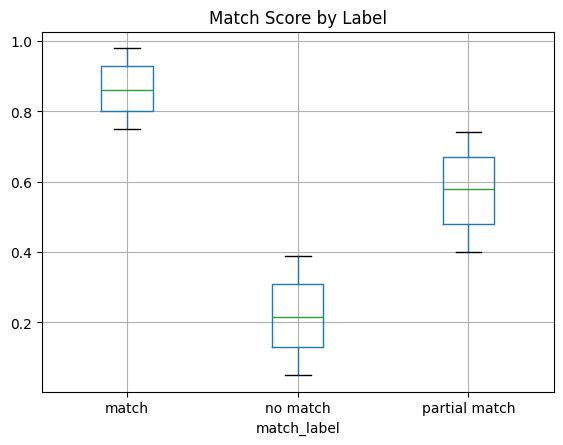

In [20]:
plt.figure(figsize=(10,6))
dataset.boxplot(column='match_score', by='match_label')
plt.title("Match Score by Label")
plt.suptitle("")
plt.show()

In [21]:
# Side-by-side comparison
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'  Base MAE:         {base_mae:.4f}')
print(f'  Fine-tuned MAE:   {ft_mae:.4f}')
print(f'  Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:         0.2222
  Fine-tuned MAE:   0.1543
  Improvement:      30.6%


In [22]:
metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'resumeJD2_pairs.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           10,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

with open('/content/drive/MyDrive/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: content/drive/MyDrive/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: content/drive/MyDrive/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "resumeJD2_pairs.csv",
  "total_pairs": 500,
  "train_pairs": 400,
  "val_pairs": 50,
  "test_pairs": 50,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.2222,
  "finetuned_mae": 0.1543,
  "improvement_pct": 30.56
}


In [ ]:
test_cases = [
    {
        "label": "MATCH",
        "resume": """
        Software Engineer with 5 years of experience in Python development.
        Skilled in Django, FastAPI, REST APIs, PostgreSQL, AWS, Docker, and Git.
        Developed scalable backend services and deployed applications on cloud platforms.
        """,
        "jd": """
        Looking for a Backend Python Developer with experience in Django or FastAPI.
        Must have knowledge of REST APIs, PostgreSQL, Docker, AWS, and Git.
        Experience building scalable backend systems is required.
        """
    },

    {
        "label": "PARTIAL MATCH",
        "resume": """
        Full Stack Developer with 3 years of experience in React.js, JavaScript,
        Node.js, Express.js, MongoDB, and basic AWS deployment.
        Worked on frontend-heavy web applications and APIs.
        """,
        "jd": """
        Hiring Python Full Stack Developer.
        Required skills include React.js, Python, Django, PostgreSQL,
        AWS, and REST API development.
        Minimum 4 years of experience preferred.
        """
    },

    {
        "label": "NO MATCH",
        "resume": """
        Human Resources Manager with 8 years of experience in recruitment,
        employee engagement, payroll management, performance reviews,
        and talent acquisition.
        """,
        "jd": """
        Data Scientist required with expertise in Python, Machine Learning,
        Deep Learning, SQL, NLP, TensorFlow, and data visualization.
        """
    },

    {
        "label": "MATCH",
        "resume": """
        Data Scientist with 4 years of experience in Machine Learning,
        Deep Learning, NLP, Python, Pandas, Scikit-learn, TensorFlow,
        and SQL. Built predictive analytics and recommendation systems.
        """,
        "jd": """
        Seeking Data Scientist proficient in Python, Machine Learning,
        TensorFlow, NLP, SQL, and predictive modeling.
        Experience building recommendation systems is preferred.
        """
    },

    {
        "label": "PARTIAL MATCH",
        "resume": """
        DevOps Engineer with expertise in Docker, Kubernetes,
        CI/CD pipelines, Linux administration, Jenkins, AWS,
        and infrastructure automation.
        """,
        "jd": """
        Cloud Engineer needed with AWS, Terraform, Kubernetes,
        Docker, networking, and Python scripting experience.
        """
    },

    {
        "label": "NO MATCH",
        "resume": """
        Chartered Accountant with experience in taxation,
        auditing, financial reporting, GST compliance,
        and corporate finance.
        """,
        "jd": """
        Senior Java Developer required with Spring Boot,
        Microservices, Kafka, MySQL, and AWS experience.
        """
    },

    {
        "label": "MATCH",
        "resume": """
        Machine Learning Engineer with 6 years of experience in Python,
        TensorFlow, PyTorch, Scikit-learn, and NLP. Built production-ready
        recommendation systems and deployed ML models on AWS.
        """,
        "jd": """
        Hiring Machine Learning Engineer with strong Python skills.
        Must have experience in TensorFlow, PyTorch, Scikit-learn,
        NLP, and deploying ML models on AWS.
        """
    },

    {
        "label": "MATCH",
        "resume": """
        Frontend Developer with 4 years of experience in Angular,
        TypeScript, HTML, CSS, and UI/UX design. Built responsive
        web applications and optimized performance.
        """,
        "jd": """
        Looking for React.js Frontend Developer with experience in
        TypeScript, HTML, CSS, and UI/UX design. Knowledge of Angular
        is a plus. Minimum 5 years of experience required.
        """
    },

    {
        "label": "NO MATCH",
        "resume": """
        Mechanical Engineer with 10 years of experience in CAD design,
        SolidWorks, manufacturing processes, and quality assurance.
        """,
        "jd": """
        Cybersecurity Analyst required with expertise in Python,
        penetration testing, SIEM tools, threat modeling, and
        vulnerability assessment.
        """
    },

    {
        "label": "MATCH",
        "resume": """
        Cloud Architect with 7 years of experience in AWS, Azure,
        Kubernetes, Docker, Terraform, CI/CD pipelines, and cloud
        security best practices.
        """,
        "jd": """
        Seeking Cloud Architect with expertise in AWS, Azure,
        Kubernetes, Docker, Terraform, and CI/CD pipelines.
        Knowledge of cloud security is essential.
        """
    }
]


In [24]:
def score_resume_against_jd(resume_text, jd_text, model):
 
    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text,     convert_to_numpy=True)
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)

In [27]:
print('Production Pipeline Test')
print('=' * 60)
for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'match' if score > 0.75 else 'partial match' if score > 0.45 else 'no match'
    print(f"\n{case['label']}")
    print(f"  Predicted score: {score:.4f}  →  {label}")


Production Pipeline Test

MATCH
  Predicted score: 0.8225  →  match

PARTIAL MATCH
  Predicted score: 0.6719  →  partial match

NO MATCH
  Predicted score: 0.2986  →  no match

MATCH
  Predicted score: 0.8495  →  match

PARTIAL MATCH
  Predicted score: 0.7272  →  partial match

NO MATCH
  Predicted score: 0.1890  →  no match

MATCH
  Predicted score: 0.8149  →  match

PARTIAL MATCH
  Predicted score: 0.8073  →  match

NO MATCH
  Predicted score: 0.2068  →  no match

MATCH
  Predicted score: 0.9222  →  match
